## 1. Load files

In [1]:
import warnings
warnings.filterwarnings("ignore")

from langchain_community.document_loaders import TextLoader
from langchain_core.documents import Document
from pathlib import Path

DATA_DIR = "./cleaned_docs"

all_docs = []
for txt_file in sorted(Path(DATA_DIR).glob("*.txt")):
    loader = TextLoader(str(txt_file), encoding="utf-8")
    docs = loader.load()
    
    for doc in docs:
        lines = doc.page_content.splitlines()
        url = lines[0].strip() if lines else ""
        content = "\n".join(lines[1:]).strip()
        
        stem = txt_file.stem  # removes .txt
        page_title = ".".join(stem.split(".")[1:])  
        
        all_docs.append(Document(
            page_content=content,
            metadata={
                "source": txt_file.name,
                "url": url,
                "page_title": page_title
            }
        ))

print(f"Total files loaded : {len(all_docs)}")
print(f"Total characters   : {sum(len(d.page_content) for d in all_docs):,}")
print(f"\nSample metadata    : {all_docs[0].metadata}")
print(f"First 300 chars    :\n{all_docs[0].page_content[:300]}")

Total files loaded : 377
Total characters   : 2,950,755

Sample metadata    : {'source': '1.netsoltech.com.txt', 'url': 'https://netsoltech.com/', 'page_title': 'netsoltech.com'}
First 300 chars    :
Shaping Smarter Finance
AI-enabled ecosystems
that make commerce
secure
We remove complexity from the asset lifecycle with a composable platform that integrates effortlessly.
The world's leading brands are powered by NETSOL
Transcend Platform
An AI-driven, composable platform for lenders, OEMs, deal


## 2. Chunking

In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
    separators=["\n\n", "\n", ". ", " ", ""],
    length_function=len,
)

chunks = splitter.split_documents(all_docs)

print(f"Total documents    : {len(all_docs)}")
print(f"Total chunks       : {len(chunks)}")
sizes = [len(c.page_content) for c in chunks]
print(f"Avg chunk size     : {sum(sizes)//len(sizes)} chars")
print(f"Min / Max          : {min(sizes)} / {max(sizes)} chars")
print(f"\nSample chunk metadata : {chunks[0].metadata}")
print(f"\nChunk 0 preview:\n{chunks[0].page_content}")

Total documents    : 377
Total chunks       : 3820
Avg chunk size     : 792 chars
Min / Max          : 13 / 1000 chars

Sample chunk metadata : {'source': '1.netsoltech.com.txt', 'url': 'https://netsoltech.com/', 'page_title': 'netsoltech.com'}

Chunk 0 preview:
Shaping Smarter Finance
AI-enabled ecosystems
that make commerce
secure
We remove complexity from the asset lifecycle with a composable platform that integrates effortlessly.
The world's leading brands are powered by NETSOL
Transcend Platform
An AI-driven, composable platform for lenders, OEMs, dealers and fleets uniting digital retail, asset finance, and loan servicing with trust and transparency.
Digital Retail
Finance
AI Labs
Marketplace
Consultancy
Transcend Retail
End-to-end orchestration for OEMs and dealers. Modular and scalable to unify showroom and online journeys into one seamless retail experience.
Auto retail redefined. Personalized paths, connected touchpoints and AI-driven precision.
OEMs
Independent dealers
Deale

In [3]:
small_chunks = [(i, c) for i, c in enumerate(chunks) if len(c.page_content) < 50]
print(f"Chunks under 50 chars: {len(small_chunks)}")
for i, c in small_chunks:
    print(f"\nChunk {i} | source: {c.metadata['source']}")
    print(f"Content: '{c.page_content}'")

Chunks under 50 chars: 6

Chunk 2608 | source: 307.blog_the-switch-from-car-as-a-service-to-battery-as-a-service.txt
Content: 'Innovation of Battery-as-a-Service'

Chunk 3050 | source: 336.blog_china-finance-and-leasing-industry-an-outlook-on-where-its-headed.txt
Content: 'Auto Industry'

Chunk 3200 | source: 345.blog_the-future-of-mobility-mapping-progress-within-the-transportation-space.txt
Content: 'Automotive Artificial Intelligence Matures'

Chunk 3391 | source: 355.blog_enterprise-mobility-the-paradigm-shift.txt
Content: 'Benefits of BYOD Model, Native and Hybrid Apps'

Chunk 3664 | source: 42.terms-of-use.txt
Content: '12. INDEMNIFICATION'

Chunk 3667 | source: 42.terms-of-use.txt
Content: '13. MESSAGE BOARDS'


## 3. Ebedding & Vector Store

In [4]:
from dotenv import load_dotenv
load_dotenv(override=True)

from langchain_community.vectorstores import FAISS

from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview", output_dimensionality=1536)

vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

print(f"Vectorstore created successfully")
print(f"Total vectors stored: {vectorstore.index.ntotal}")

Vectorstore created successfully
Total vectors stored: 3820


In [5]:
query = "Who is ceo of netsole?"
results = vectorstore.similarity_search(query, k=3)
print(f"\nTest query: '{query}'")
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(f"Source : {doc.metadata['source']}")
    print(f"URL    : {doc.metadata['url']}")
    print(f"Preview: {doc.page_content[:200]}")


Test query: 'Who is ceo of netsole?'

--- Result 1 ---
Source : 5.about-us_management-team.txt
URL    : https://netsoltech.com/about-us/management-team
Preview: Management Team
Blending decades of global experience across technology, finance, and operations to fuel growth and innovation.
Najeeb Ghauri
Founder, Chairman &
Chief Executive Officer,
NETSOL Techno

--- Result 2 ---
Source : 2.about-us_board-of-directors.txt
URL    : https://netsoltech.com/about-us/board-of-directors
Preview: Board of Directors
Visionary governance rooted in real-world experience
Najeeb Ghauri
Director, Chief Executive Officer and Chair of the Board, NetSol Technologies, Inc
View Profile
Syed Kausar Kazmi


--- Result 3 ---
Source : 5.about-us_management-team.txt
URL    : https://netsoltech.com/about-us/management-team
Preview: Amanda Li Linjie
President, NETSOL Technologies, China.
Sardar Abubakr
Chief Financial Officer, NETSOL Technologies, Inc.
Khurram S. Rana
Global CHRO - NETSOL Technologies Inc.
Kamra

In [6]:
vectorstore.save_local("faiss_db")

## 4. Visualization

In [7]:
faiss_index = vectorstore.index

vectors = faiss_index.reconstruct_n(
    0,
    faiss_index.ntotal
)

print(vectors.shape)

(3820, 1536)


In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
points = pca.fit_transform(vectors)

print(points.shape)

(3820, 2)


In [9]:
docstore = vectorstore.docstore._dict
index_to_docstore_id = vectorstore.index_to_docstore_id

labels = [
    docstore[index_to_docstore_id[i]].metadata.get("source", "unknown")
    for i in range(vectorstore.index.ntotal)
]

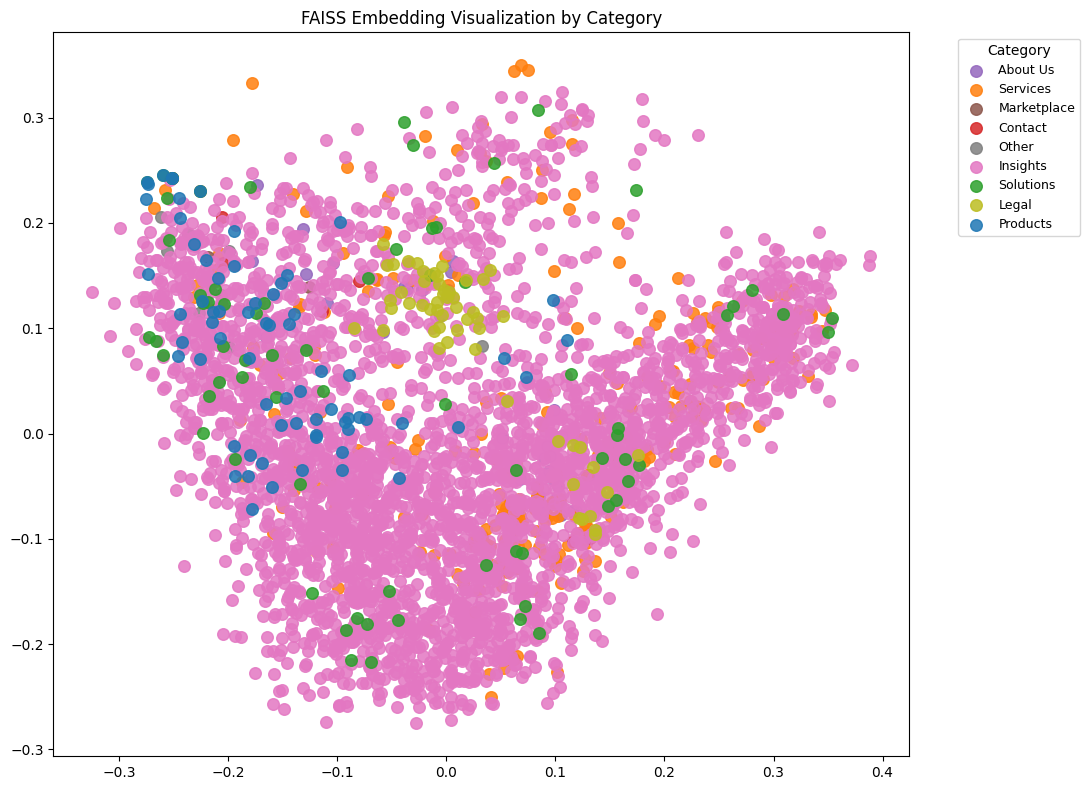

In [11]:

import matplotlib.pyplot as plt
def get_category(source):
    name = source.replace(".txt", "")
    parts = name.split(".")[1:]
    joined = "_".join(parts)
    
    if "product" in joined:
        return "Products"
    elif "solution" in joined:
        return "Solutions"
    elif "service" in joined:
        return "Services"
    elif "about" in joined:
        return "About Us"
    elif "insight" in joined or "blog" in joined:
        return "Insights"
    elif "contact" in joined:
        return "Contact"
    elif "marketplace" in joined:
        return "Marketplace"
    elif "privacy" in joined or "terms" in joined or "cookie" in joined:
        return "Legal"
    elif joined == "netsoltech.com":
        return "Home"
    else:
        return "Other"

cat_colors = {
    "Products":    "#1f77b4",
    "Solutions":   "#2ca02c",
    "Services":    "#ff7f0e",
    "About Us":    "#9467bd",
    "Insights":    "#e377c2",
    "Contact":     "#d62728",
    "Marketplace": "#8c564b",
    "Legal":       "#bcbd22",
    "Home":        "#17becf",
    "Other":       "#7f7f7f",
}

categories = [get_category(l) for l in labels]
unique_cats = list(set(categories))

plt.figure(figsize=(11, 8))
for cat in unique_cats:
    idx = [i for i, c in enumerate(categories) if c == cat]
    plt.scatter(
        points[idx, 0],
        points[idx, 1],
        c=cat_colors.get(cat, "#7f7f7f"),
        label=cat,
        alpha=0.85,
        s=70
    )

plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.title("FAISS Embedding Visualization by Category")
plt.tight_layout()
plt.show()

In [1]:
import warnings
warnings.filterwarnings("ignore")

from langchain_community.document_loaders import TextLoader
from langchain_core.documents import Document
from pathlib import Path

DATA_DIR = "./cleaned_docs"

all_docs = []
for txt_file in sorted(Path(DATA_DIR).glob("*.txt")):
    loader = TextLoader(str(txt_file), encoding="utf-8")
    docs = loader.load()
    
    for doc in docs:
        lines = doc.page_content.splitlines()
        url = lines[0].strip() if lines else ""
        content = "\n".join(lines[1:]).strip()
        
        stem = txt_file.stem  # removes .txt
        page_title = ".".join(stem.split(".")[1:])  
        
        all_docs.append(Document(
            page_content=content,
            metadata={
                "source": txt_file.name,
                "url": url,
                "page_title": page_title
            }
        ))

print(f"Total files loaded : {len(all_docs)}")
print(f"Total characters   : {sum(len(d.page_content) for d in all_docs):,}")
print(f"\nSample metadata    : {all_docs[0].metadata}")
print(f"First 300 chars    :\n{all_docs[0].page_content[:300]}")

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
    separators=["\n\n", "\n", ". ", " ", ""],
    length_function=len,
)

chunks = splitter.split_documents(all_docs)

print(f"Total documents    : {len(all_docs)}")
print(f"Total chunks       : {len(chunks)}")
sizes = [len(c.page_content) for c in chunks]
print(f"Avg chunk size     : {sum(sizes)//len(sizes)} chars")
print(f"Min / Max          : {min(sizes)} / {max(sizes)} chars")
print(f"\nSample chunk metadata : {chunks[0].metadata}")
print(f"\nChunk 0 preview:\n{chunks[0].page_content}")

In [4]:
from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = OllamaEmbeddings(
    model="mxbai-embed-large:latest"
)

vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

print(f"Vectorstore created successfully")
print(f"Total vectors stored: {vectorstore.index.ntotal}")

In [1]:
import warnings
warnings.filterwarnings("ignore")

from langchain_community.document_loaders import TextLoader
from langchain_core.documents import Document
from pathlib import Path

DATA_DIR = "./cleaned_docs"

all_docs = []
for txt_file in sorted(Path(DATA_DIR).glob("*.txt")):
    loader = TextLoader(str(txt_file), encoding="utf-8")
    docs = loader.load()
    
    for doc in docs:
        lines = doc.page_content.splitlines()
        url = lines[0].strip() if lines else ""
        content = "\n".join(lines[1:]).strip()
        
        stem = txt_file.stem  # removes .txt
        page_title = ".".join(stem.split(".")[1:])  
        
        all_docs.append(Document(
            page_content=content,
            metadata={
                "source": txt_file.name,
                "url": url,
                "page_title": page_title
            }
        ))

print(f"Total files loaded : {len(all_docs)}")
print(f"Total characters   : {sum(len(d.page_content) for d in all_docs):,}")
print(f"\nSample metadata    : {all_docs[0].metadata}")
print(f"First 300 chars    :\n{all_docs[0].page_content[:300]}")